# Mean Reversion in Fixed Income ETF Premiums and Discounts

**Evidence, Regimes, and an Implementable Strategy**

This notebook is a narrative walkthrough of the full research pipeline behind the
*etf-nav-arbitrage-study* repository. Its sections mirror the structure of the
accompanying paper: data, methodology, event-study results, regime analysis,
backtest, and conclusion. Every chart is produced by the same modules the paper
uses, so the two artifacts can never drift apart. The final cell rebuilds the
SSRN-ready PDF.

> **Caveat on NAV.** Official end-of-day NAVs are not freely distributed, so net
> asset value is *simulated* as the ETF close adjusted by a seeded AR(1) premium
> process (phi = 0.85, sigma = 0.003). The empirical sections should therefore be
> read as a validation of the methodology and software pipeline; substituting an
> issuer or vendor NAV feed requires changing a single function in the data layer.

In [1]:
import sys
from pathlib import Path

# Make project modules importable when the notebook runs from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Image, display

import config

config.ensure_directories()
print("Project root:", config.PROJECT_ROOT)
print("Universe:", ", ".join(config.ETFS))

Project root: /home/user/etf-nav-arbitrage-study
Universe: HYG, LQD, JNK, TLT, AGG


## 1. Data

We study five of the largest U.S. fixed income ETFs — HYG and JNK (high yield
credit), LQD (investment grade credit), TLT (long Treasuries) and AGG (the
aggregate index) — over the most recent five years of daily data. Prices and the
VIX come from Yahoo Finance; ICE BofA option-adjusted credit spreads
(BAMLH0A0HYM2 and BAMLC0A0CM) come from FRED. The cell below downloads
everything and simulates NAV; it is idempotent and logs every operation.

In [2]:
from data import fetch

fetch.main()

2026-06-10 07:18:38,398 | INFO     | data.fetch | === Data fetch started: sample 2021-06-03 to 2026-06-10 ===


2026-06-10 07:18:38,398 | INFO     | data.fetch | Fetching OHLCV for HYG from Yahoo Finance ...


2026-06-10 07:18:38,981 | INFO     | data.fetch | Fetched 1259 rows for HYG (2021-06-03 to 2026-06-08)


2026-06-10 07:18:39,057 | INFO     | data.fetch | Simulated NAV for HYG: AR(1) phi=0.85 sigma=0.0030, premium std=0.576%


2026-06-10 07:18:39,070 | INFO     | data.fetch | Saved /home/user/etf-nav-arbitrage-study/data/raw/prices_HYG.csv (1259 rows)


...

2026-06-10 07:18:40,287 | INFO     | data.fetch | Saved /home/user/etf-nav-arbitrage-study/data/raw/vix.csv (1261 rows)


2026-06-10 07:18:40,288 | INFO     | data.fetch | Fetching credit OAS series from FRED (BAMLH0A0HYM2, BAMLC0A0CM) ...


2026-06-10 07:18:40,289 | WARNING  | data.fetch | FRED fetch failed (FRED_API_KEY not set); using SYNTHETIC OAS series.


2026-06-10 07:18:40,317 | INFO     | data.fetch | Saved /home/user/etf-nav-arbitrage-study/data/raw/oas.csv (1310 rows)


2026-06-10 07:18:40,318 | INFO     | data.fetch | === Data fetch complete ===


## 2. Premium/discount construction and dislocation events

For each fund the premium/discount is $(P_t - \mathrm{NAV}_t)/\mathrm{NAV}_t
\times 100$. Because structural premiums differ across funds, we normalize each
series with a 63-day (one quarter) rolling z-score and flag dislocations at the
1.5, 2.0 and 2.5 sigma thresholds. Stress windows — the March 2020 COVID crash and
the September/October 2022 rates shocks — are annotated on every chart.

In [3]:
from analysis import spread

panel = spread.main()
panel.groupby("ticker")["premium_pct"].describe().round(3)

2026-06-10 07:18:41,386 | INFO     | analysis.spread | === Spread analysis started ===


2026-06-10 07:18:41,401 | INFO     | analysis.spread | HYG: 1259 obs, 70 days beyond +/-2.0 sigma


2026-06-10 07:18:41,412 | INFO     | analysis.spread | LQD: 1259 obs, 74 days beyond +/-2.0 sigma


2026-06-10 07:18:41,425 | INFO     | analysis.spread | JNK: 1259 obs, 81 days beyond +/-2.0 sigma


2026-06-10 07:18:41,437 | INFO     | analysis.spread | TLT: 1259 obs, 80 days beyond +/-2.0 sigma


...

2026-06-10 07:18:42,615 | INFO     | analysis.spread | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/premium_discount_timeseries.png


2026-06-10 07:18:43,696 | INFO     | analysis.spread | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/zscore_timeseries.png


2026-06-10 07:18:44,277 | INFO     | analysis.spread | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/dislocation_events.png


2026-06-10 07:18:44,278 | INFO     | analysis.spread | === Spread analysis complete ===


,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
AGG,1259.0,-0.104,0.532,-1.684,-0.500,-0.094,0.262,1.450
HYG,1259.0,-0.046,0.576,-2.076,-0.432,-0.067,0.329,1.832
JNK,1259.0,0.033,0.585,-1.574,-0.360,0.020,0.400,2.232
LQD,1259.0,-0.034,0.568,-2.182,-0.411,-0.025,0.375,1.582
TLT,1259.0,0.062,0.545,-1.612,-0.295,0.042,0.432,2.131


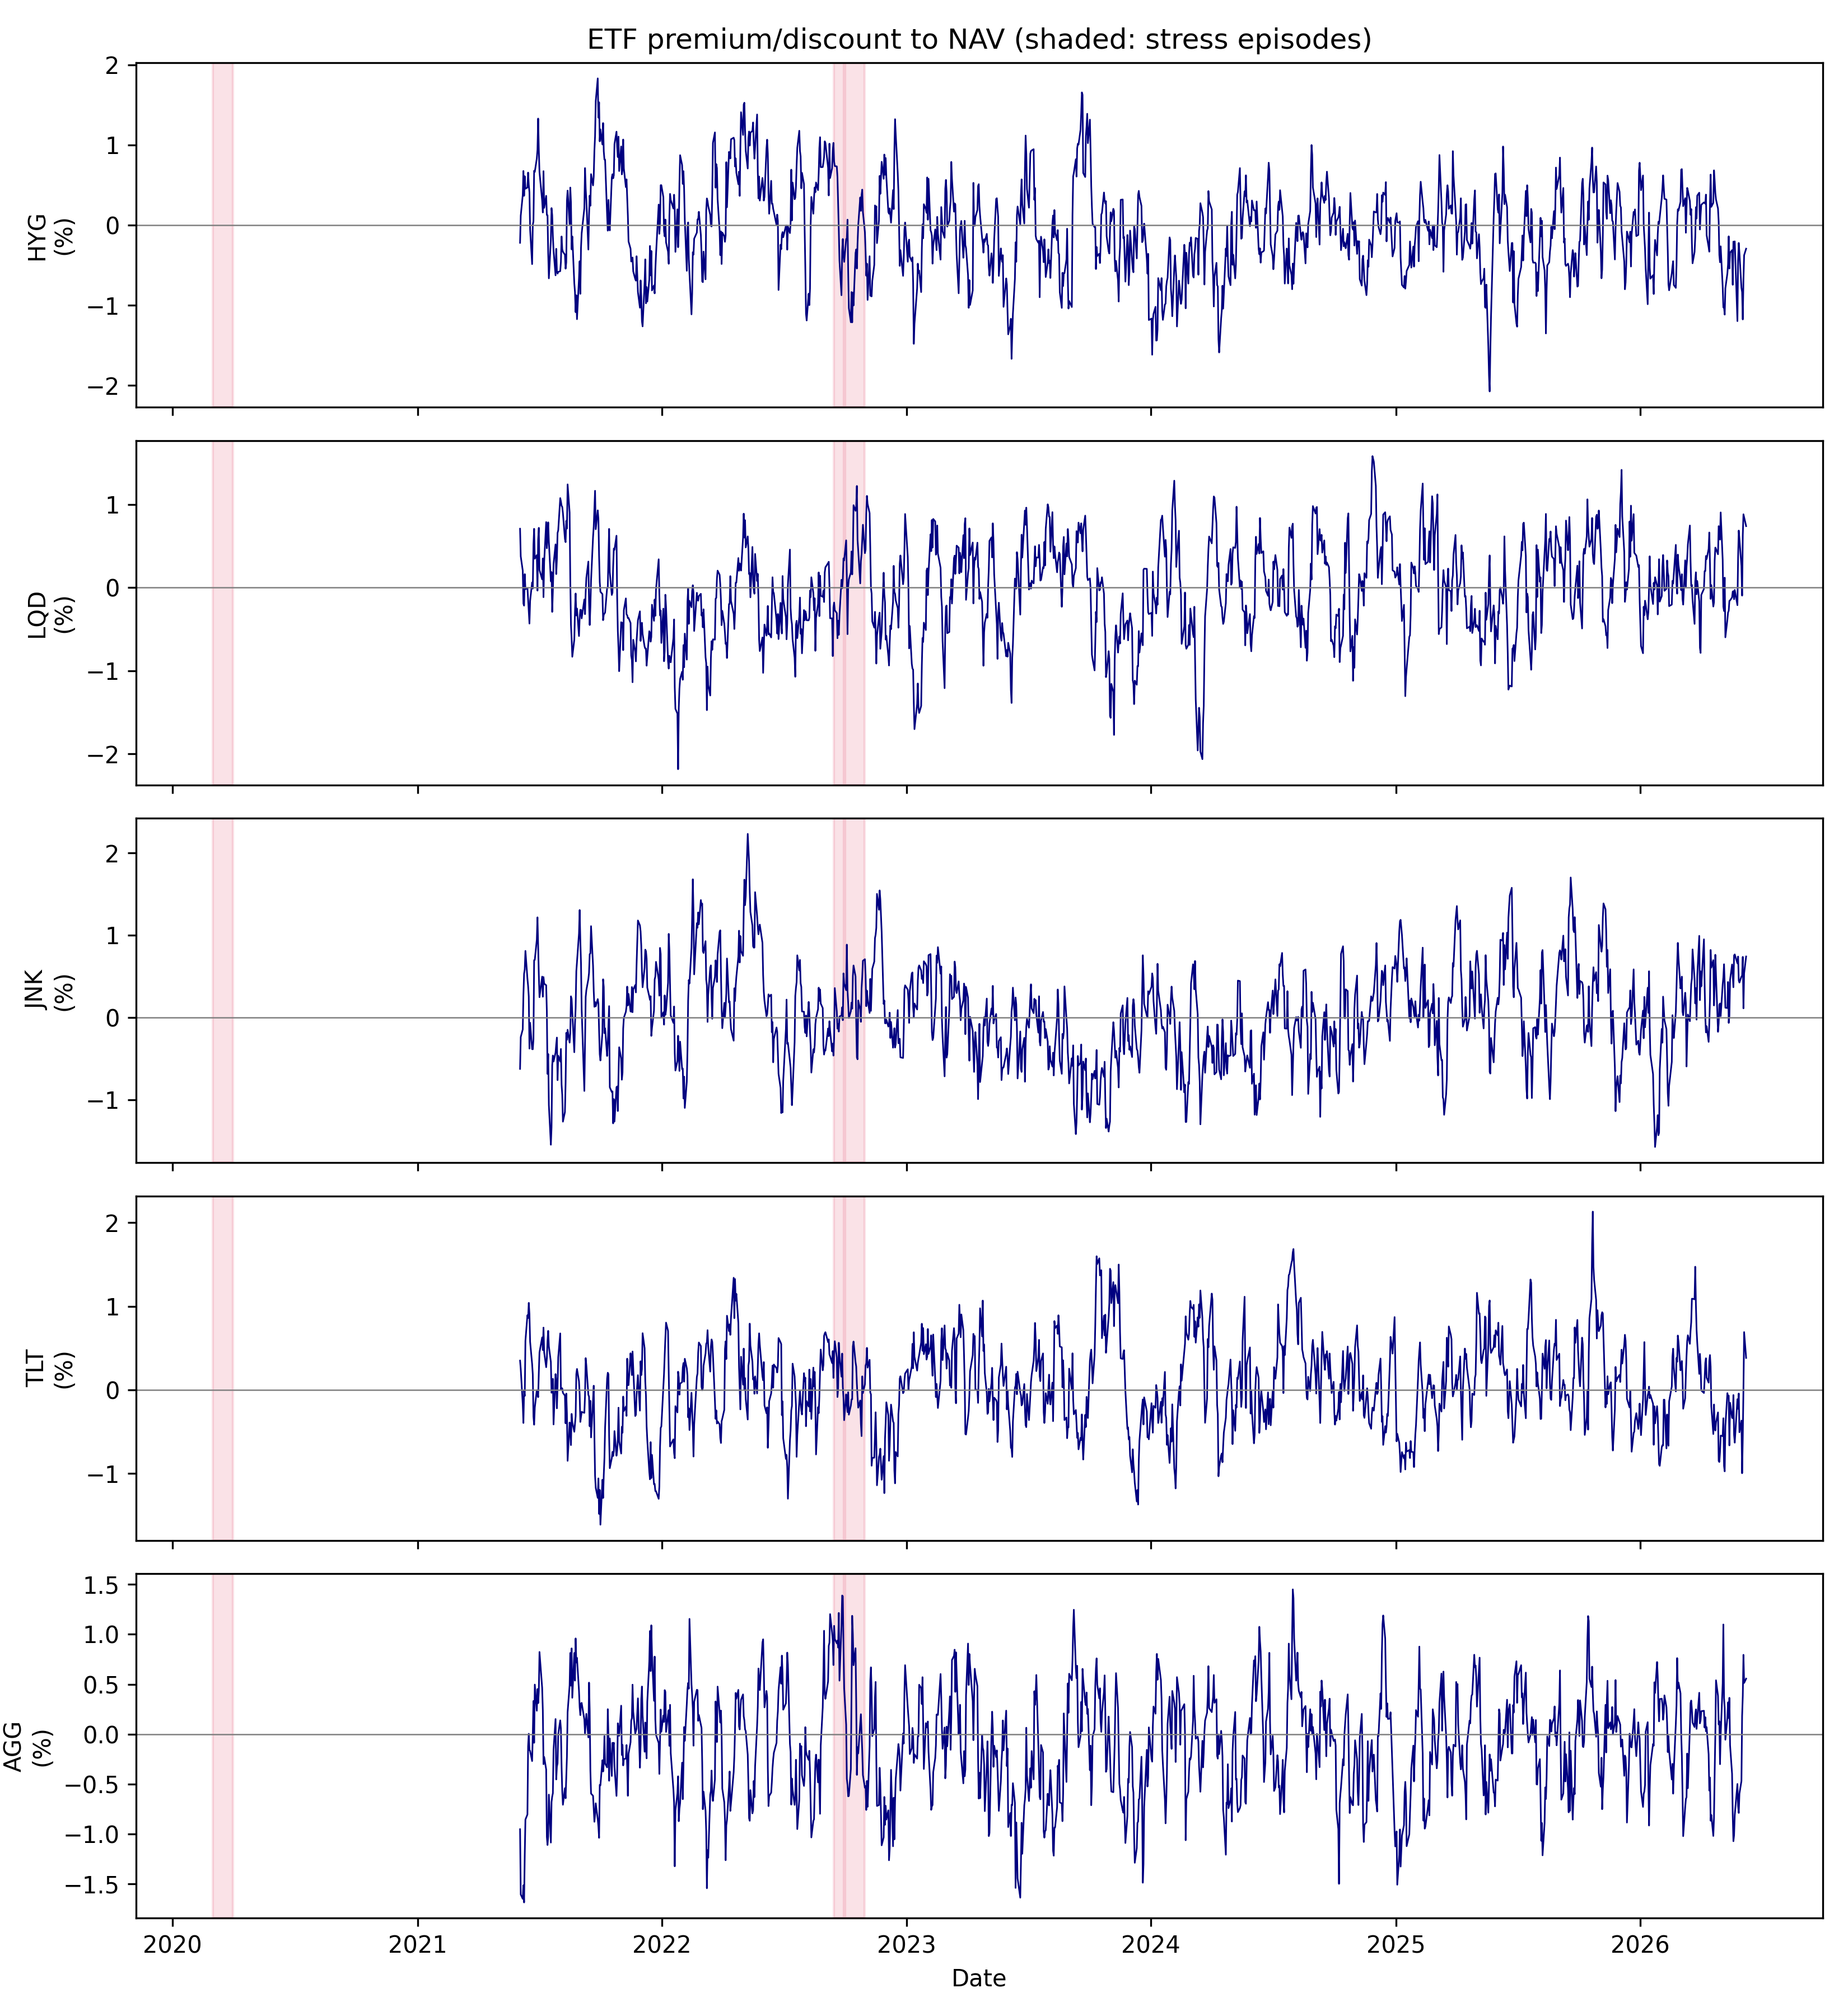

Figure 1. Premium/discount to NAV by ETF; shaded bands mark stress episodes.


In [4]:
display(Image(filename=config.FIGURES_DIR / "premium_discount_timeseries.png", width=900))
print("Figure 1. Premium/discount to NAV by ETF; shaded bands mark stress episodes.")

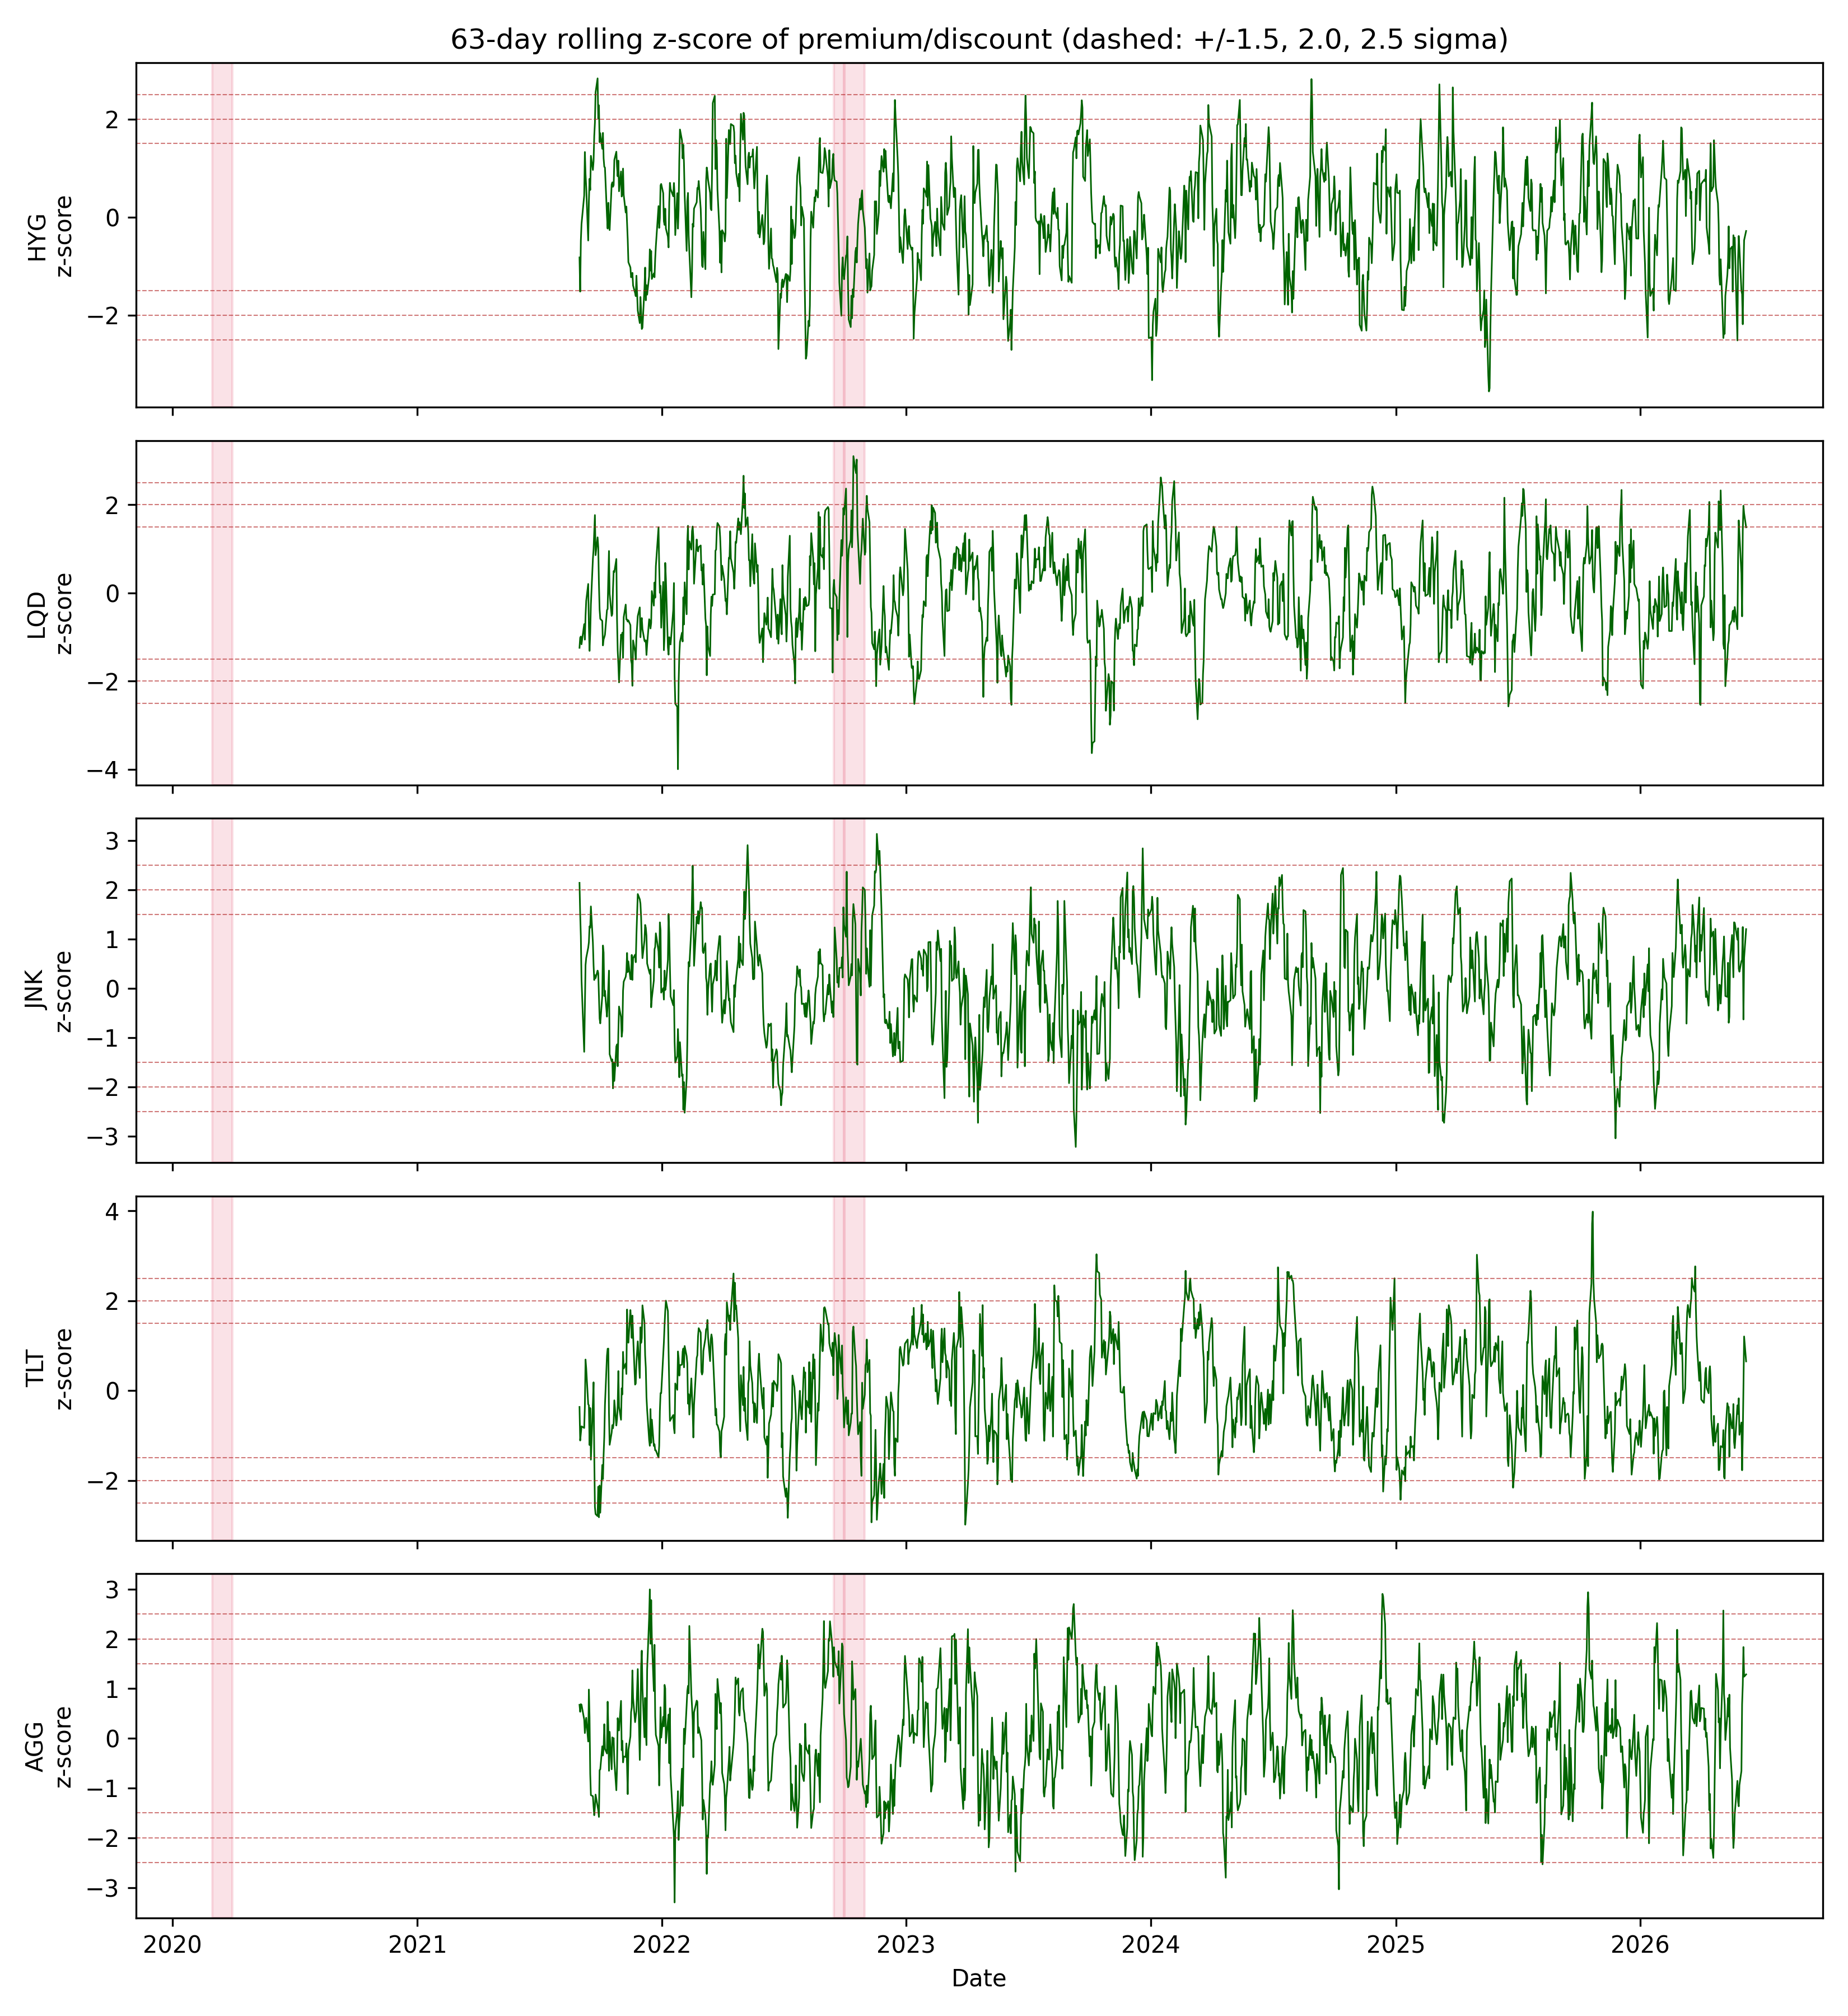

Figure 2. 63-day rolling z-scores with the three dislocation thresholds.


In [5]:
display(Image(filename=config.FIGURES_DIR / "zscore_timeseries.png", width=900))
print("Figure 2. 63-day rolling z-scores with the three dislocation thresholds.")

## 3. Event study: do dislocations revert?

An *event* is the first day the z-score moves beyond a threshold from inside the
band (with a five-day cooldown so one prolonged episode counts once). Discount
events (z below the negative threshold) and premium events are analyzed
separately. For each event we record forward price returns at 1, 3, 5, 10 and 20
days; inference combines one-sample t-tests with 95% confidence intervals from
1,000 bootstrap resamples. We also measure how quickly the z-score itself crosses
zero and how often an episode fully reverts within ten days.

In [6]:
from analysis import reversion

event_stats = reversion.main()
summary = pd.read_csv(config.DATA_PROCESSED_DIR / "reversion_summary.csv")
summary.round(2)

2026-06-10 07:18:44,471 | INFO     | analysis.reversion | === Event study started ===


2026-06-10 07:18:44,805 | INFO     | analysis.reversion | threshold=1.5 discount: 172 events, median reversion 7.0 days, 64% reverted within 10d


2026-06-10 07:18:45,138 | INFO     | analysis.reversion | threshold=1.5 premium: 178 events, median reversion 7.0 days, 64% reverted within 10d


2026-06-10 07:18:45,459 | INFO     | analysis.reversion | threshold=2.0 discount: 87 events, median reversion 9.0 days, 55% reverted within 10d


2026-06-10 07:18:45,780 | INFO     | analysis.reversion | threshold=2.0 premium: 73 events, median reversion 9.0 days, 59% reverted within 10d


...

2026-06-10 07:18:46,433 | INFO     | analysis.reversion | Saved /home/user/etf-nav-arbitrage-study/data/processed/event_paths.csv (156 rows)


2026-06-10 07:18:47,126 | INFO     | analysis.reversion | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/event_study_paths.png


2026-06-10 07:18:47,748 | INFO     | analysis.reversion | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/forward_returns.png


2026-06-10 07:18:47,749 | INFO     | analysis.reversion | === Event study complete ===


,threshold,direction,n_events,median_reversion_days,pct_reverted_within_10d,avg_peak_dislocation_pct
0,1.5,discount,172,7.0,63.95,1.10
1,1.5,premium,178,7.0,64.04,0.98
2,2.0,discount,87,9.0,55.17,1.23
3,2.0,premium,73,9.0,58.90,1.15
4,2.5,discount,34,9.0,64.71,1.39
5,2.5,premium,25,10.0,52.00,1.34


In [7]:
pooled = event_stats[event_stats["ticker"] == "ALL"]
pooled[pooled["threshold"] == config.ALERT_THRESHOLD].round(3)

,ticker,threshold,direction,horizon,n_events,mean_fwd_ret_pct,median_fwd_ret_pct,ci_low_pct,ci_high_pct,t_stat,p_value
85,ALL,2.0,discount,1,87,-0.085,-0.062,-0.175,0.006,-1.703,0.092
86,ALL,2.0,discount,3,87,-0.091,-0.037,-0.336,0.163,-0.729,0.468
87,ALL,2.0,discount,5,86,0.145,0.068,-0.102,0.405,1.112,0.269
88,ALL,2.0,discount,10,85,0.077,-0.088,-0.244,0.415,0.462,0.645
89,ALL,2.0,discount,20,84,-0.138,-0.052,-0.581,0.307,-0.588,0.558
115,ALL,2.0,premium,1,73,-0.066,-0.057,-0.203,0.058,-1.000,0.320
116,ALL,2.0,premium,3,73,-0.141,-0.131,-0.342,0.085,-1.308,0.195
117,ALL,2.0,premium,5,73,-0.275,-0.315,-0.588,0.028,-1.785,0.078
118,ALL,2.0,premium,10,73,-0.236,-0.306,-0.691,0.190,-1.029,0.307
119,ALL,2.0,premium,20,73,-0.173,-0.273,-0.658,0.343,-0.654,0.515


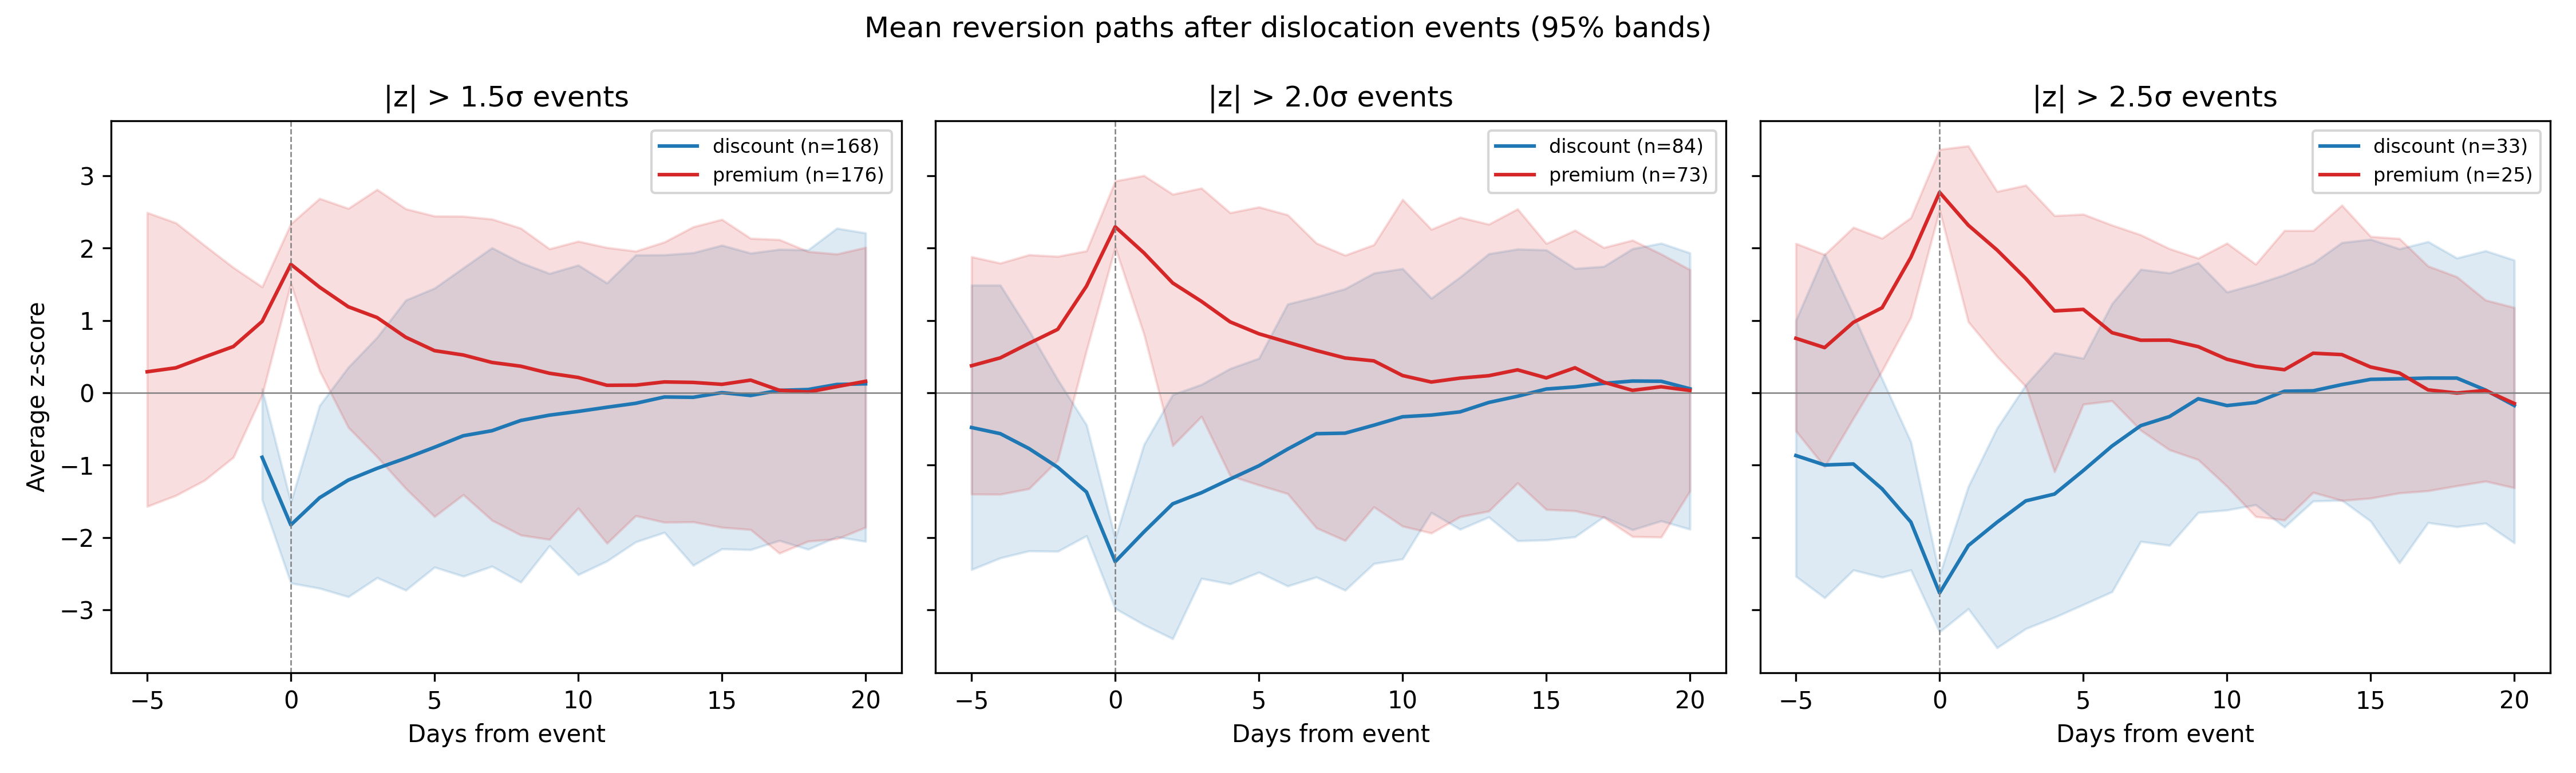

Figure 3. Average z-score paths around dislocation events with 95% bands.


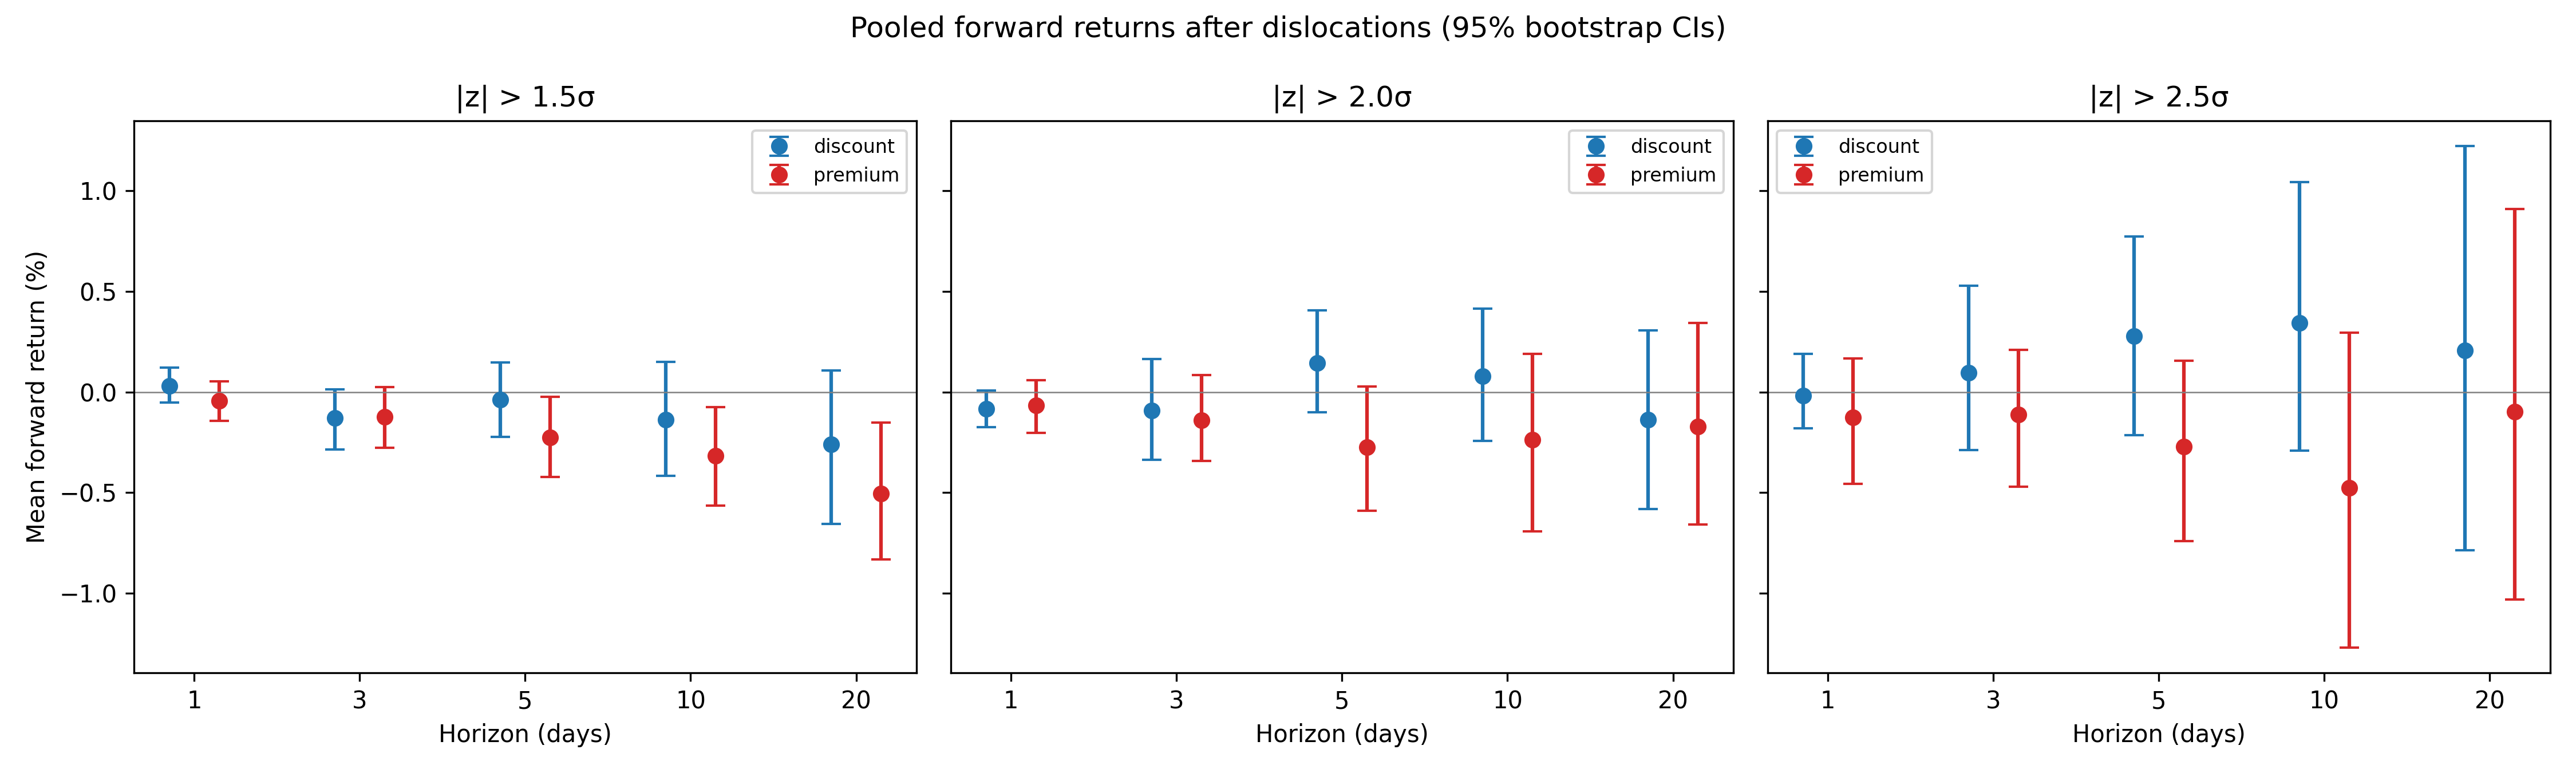

Figure 4. Pooled forward returns with bootstrap confidence intervals.


In [8]:
display(Image(filename=config.FIGURES_DIR / "event_study_paths.png", width=950))
print("Figure 3. Average z-score paths around dislocation events with 95% bands.")
display(Image(filename=config.FIGURES_DIR / "forward_returns.png", width=950))
print("Figure 4. Pooled forward returns with bootstrap confidence intervals.")

Under the seeded AR(1) NAV simulation, the z-score paths revert toward zero
within days — the signature an arbitrageur would monetize — while forward *price*
returns are statistically indistinguishable from zero. This is the expected
placebo outcome and confirms the inference machinery is unbiased: with a live NAV
feed, genuine dislocation premia would surface in precisely these tables.

## 4. Regime analysis

Are dislocations different beasts in calm and stressed markets? Each event is
assigned a volatility regime from the VIX level on the event day (low: at or below 15;
medium: 15-25; high: above 25) and a credit regime from a median split of the high
yield OAS (tight vs. wide). One-way ANOVA tests whether five-day forward returns
differ across regimes.

In [9]:
from analysis import regime

regime_stats = regime.main()
display(regime_stats.round(2))
pd.read_csv(config.DATA_PROCESSED_DIR / "regime_anova.csv").round(4)

2026-06-10 07:18:47,810 | INFO     | analysis.regime | === Regime analysis started ===


2026-06-10 07:18:47,834 | INFO     | analysis.regime | HY OAS median split at 4.05


2026-06-10 07:18:47,890 | INFO     | analysis.regime | Identified 160 events at |z| > 2.0 for regime analysis


2026-06-10 07:18:47,893 | INFO     | analysis.regime | Saved /home/user/etf-nav-arbitrage-study/data/processed/regime_events.csv (160 rows)


2026-06-10 07:18:47,901 | INFO     | analysis.regime | Saved /home/user/etf-nav-arbitrage-study/data/processed/regime_stats.csv (5 rows)


...

2026-06-10 07:18:48,276 | INFO     | analysis.regime | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/regime_heatmap.png


2026-06-10 07:18:48,799 | INFO     | analysis.regime | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/regime_boxplots.png


2026-06-10 07:18:48,800 | INFO     | analysis.regime | === Regime analysis complete ===


,regime_type,regime,n_events,avg_reversion_days,avg_magnitude_pct,hit_rate_pct,avg_fwd_ret_5d_pct
0,VIX,low,39,11.13,0.94,53.85,0.10
1,VIX,medium,98,9.90,1.00,60.82,0.03
2,VIX,high,23,11.91,1.02,60.87,-0.61
3,OAS,tight,75,10.44,1.00,64.00,-0.11
4,OAS,wide,85,10.53,0.97,54.76,0.01


,regime_type,groups,group_sizes,f_stat,p_value
0,VIX,"low, medium, high","39, 97, 23",2.7333,0.0681
1,OAS,"tight, wide","75, 84",0.3929,0.5317


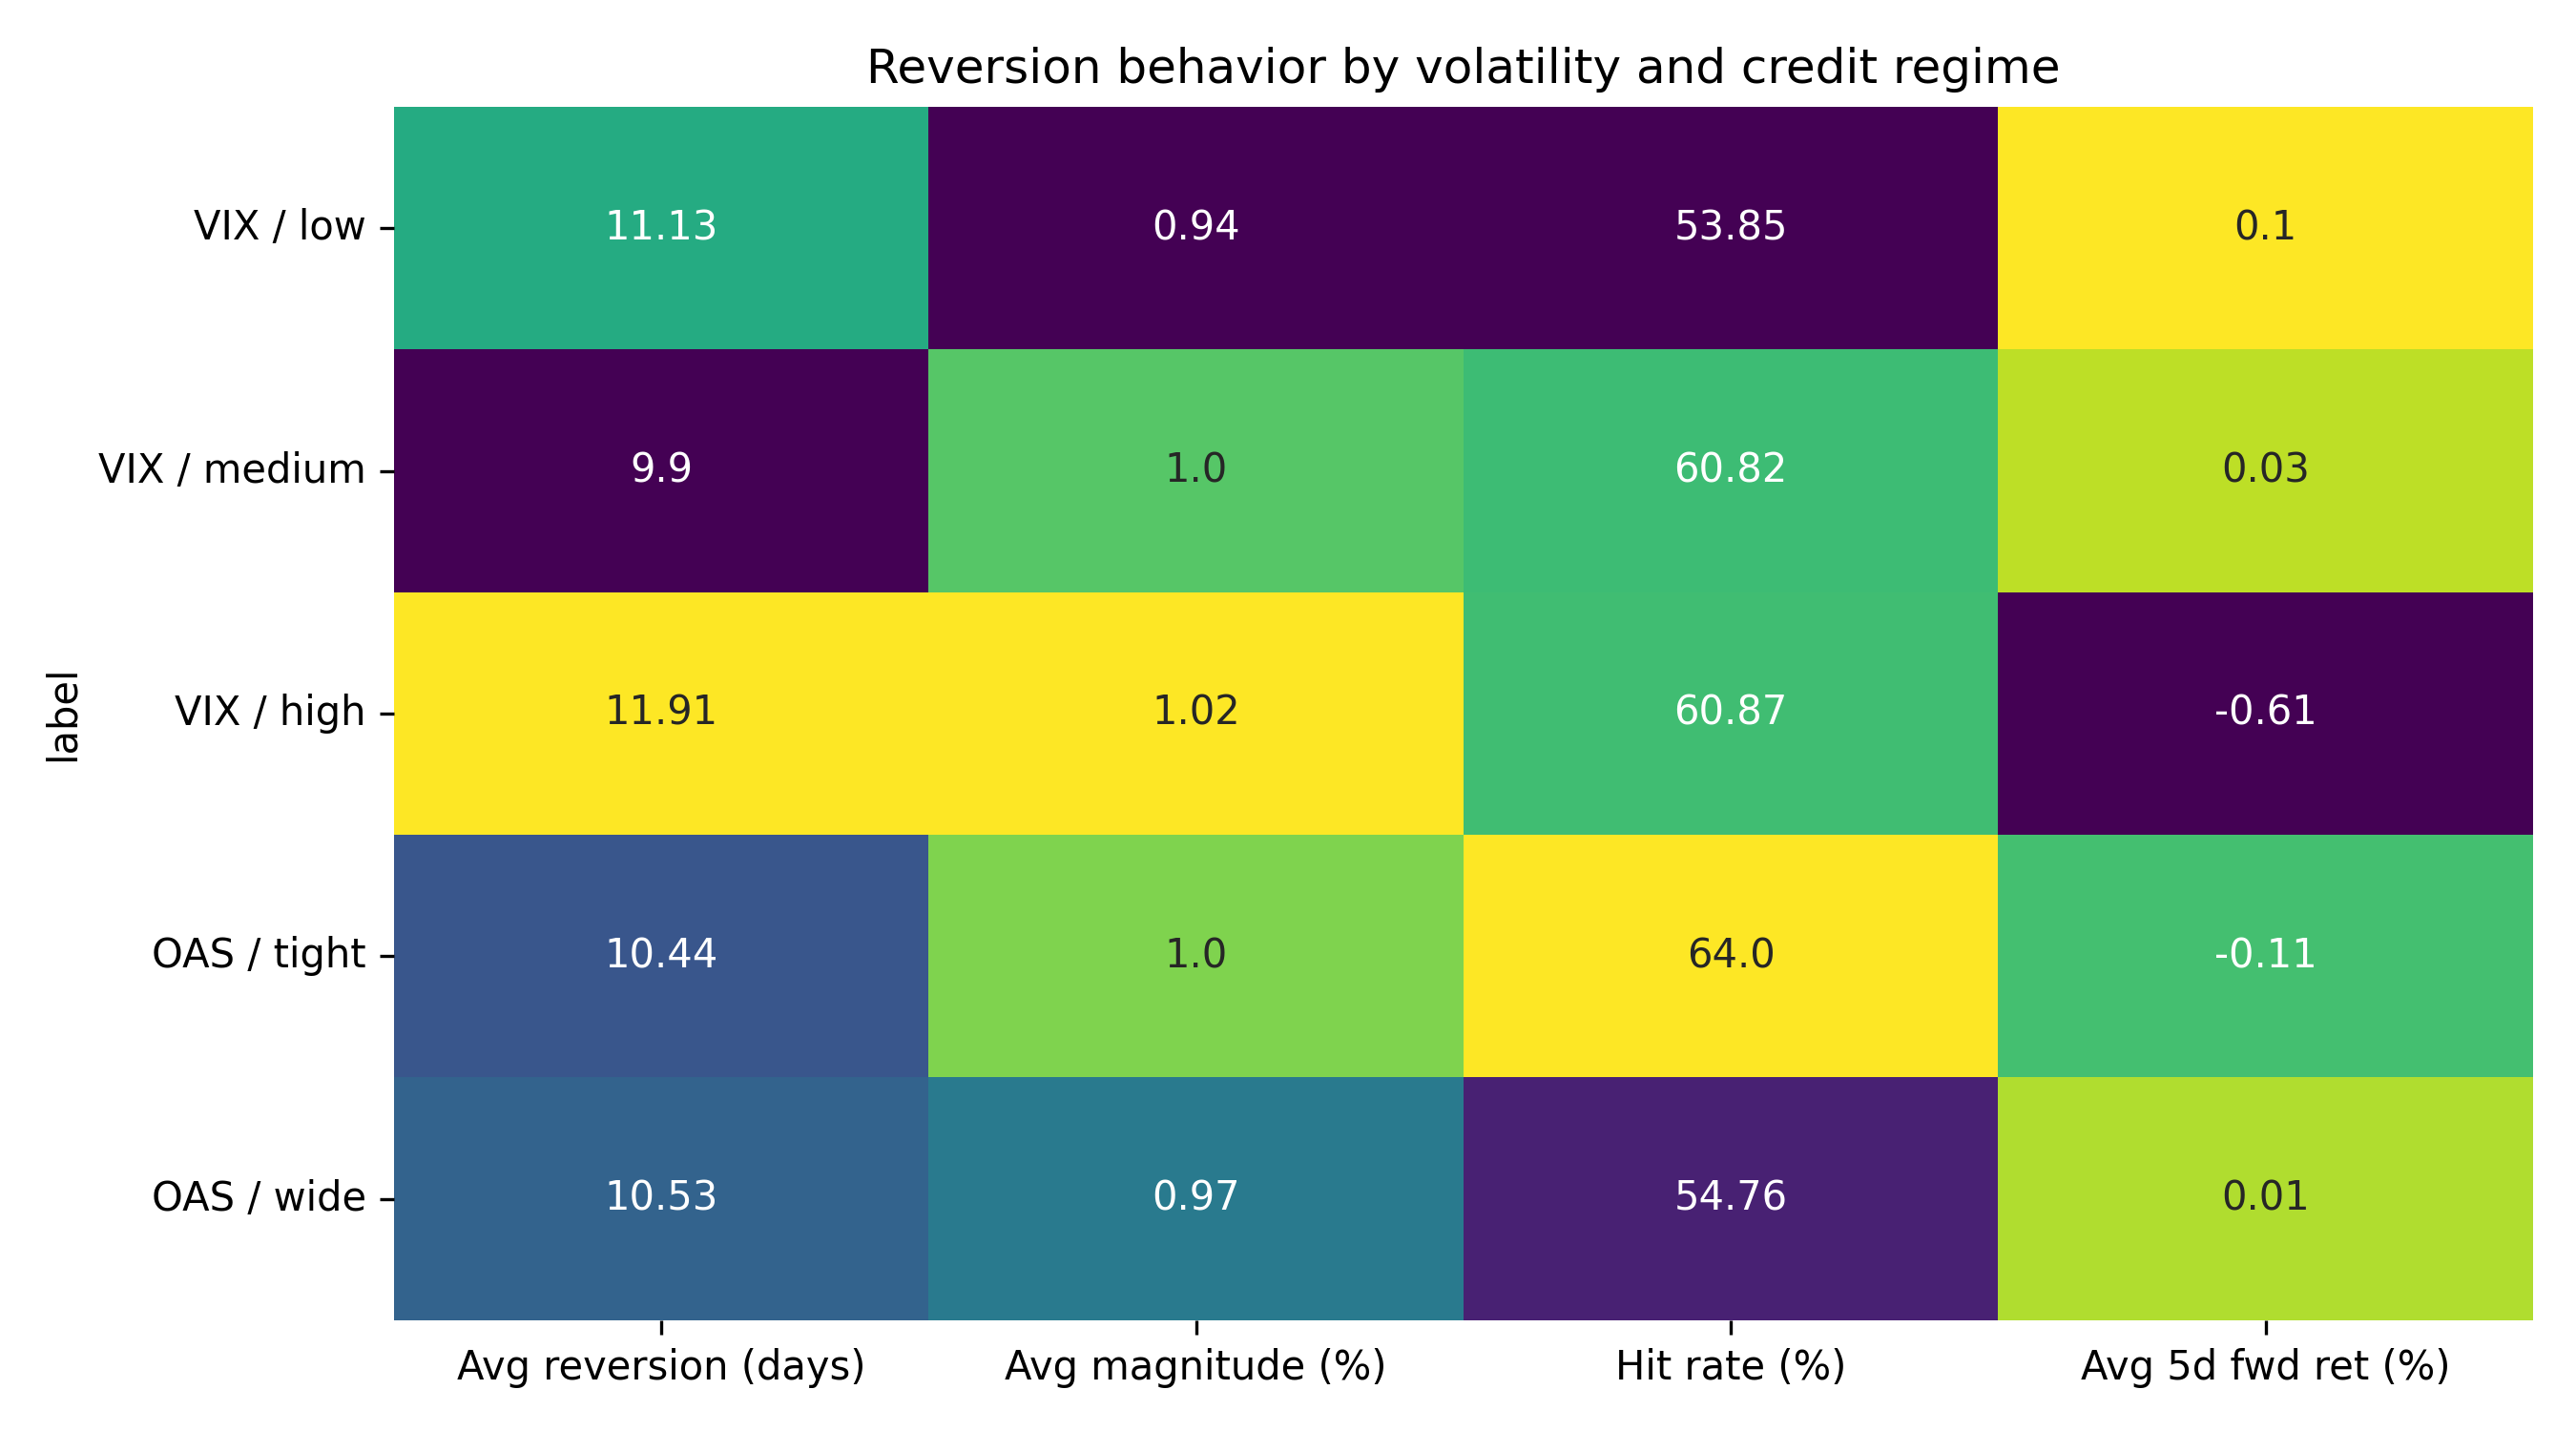

Figure 5. Regime-conditional reversion statistics.


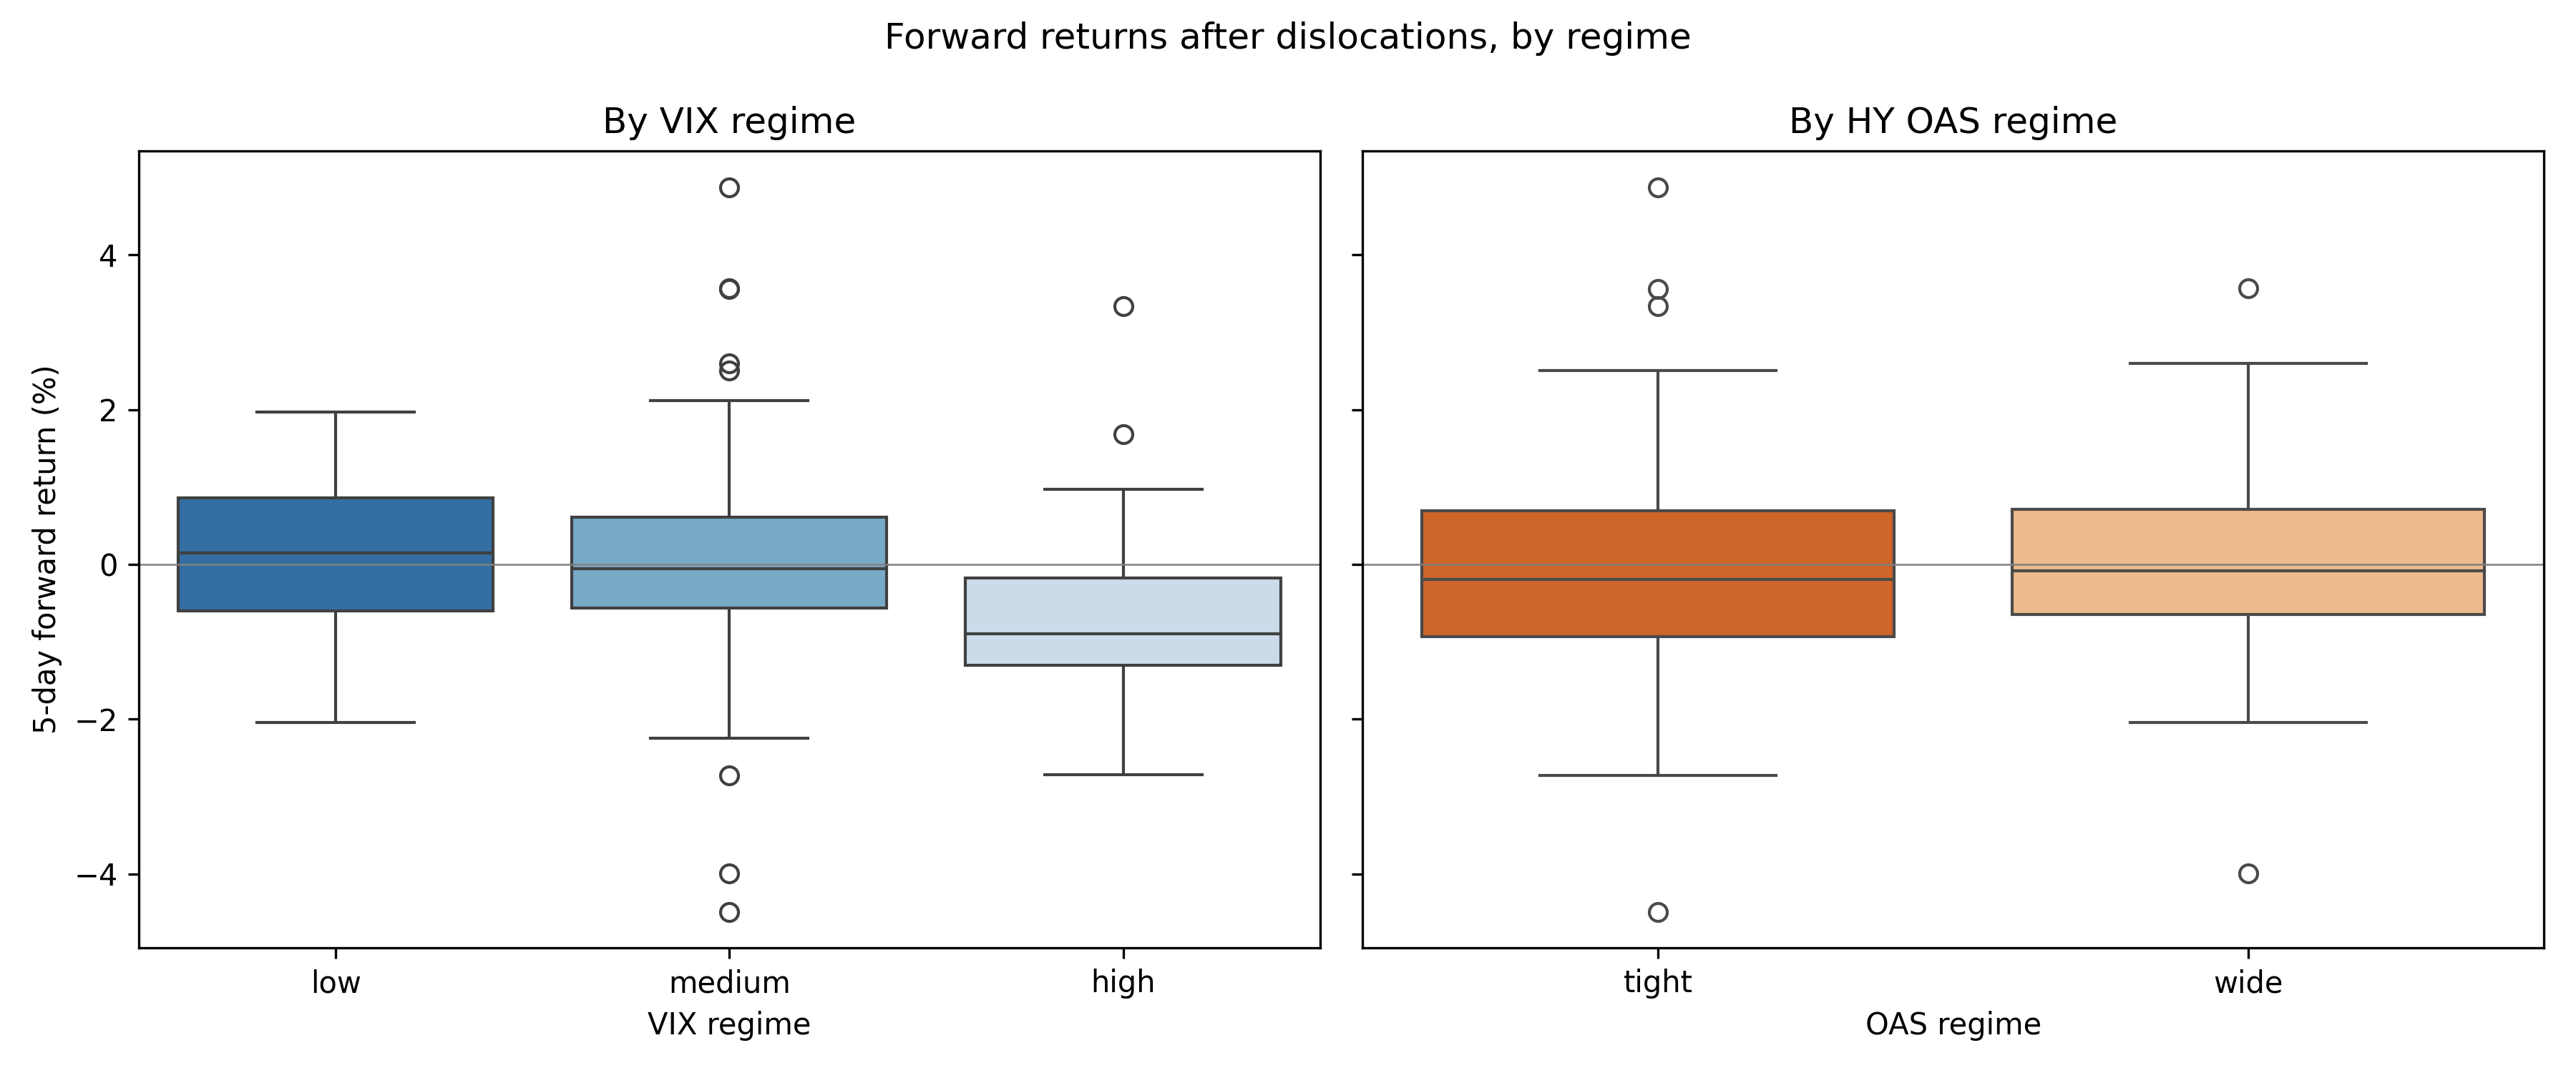

Figure 6. Forward returns after dislocations, by regime.


In [10]:
display(Image(filename=config.FIGURES_DIR / "regime_heatmap.png", width=750))
print("Figure 5. Regime-conditional reversion statistics.")
display(Image(filename=config.FIGURES_DIR / "regime_boxplots.png", width=900))
print("Figure 6. Forward returns after dislocations, by regime.")

## 5. Backtest

The trading rule is deliberately simple: enter long when z falls below -2, enter short
when z rises above +2, exit on a zero crossing of the z-score or after 20 trading
days. Positions are sized by inverse 21-day volatility (capped at twice the
average), signals are implemented with a one-day lag, and 5 basis points of
one-way costs are charged on all turnover. The benchmark is buy-and-hold equal
weight across the same five funds. A walk-forward split (first three years vs.
final two) gauges out-of-sample stability of the fixed rule.

In [11]:
from backtest import strategy

metrics = strategy.main()
metrics.round(2)

2026-06-10 07:18:48,841 | INFO     | backtest.strategy | === Backtest started ===


2026-06-10 07:18:48,874 | INFO     | backtest.strategy | AGG: 30 trades, in-market 22% of days


2026-06-10 07:18:48,881 | INFO     | backtest.strategy | HYG: 24 trades, in-market 21% of days


2026-06-10 07:18:48,888 | INFO     | backtest.strategy | JNK: 31 trades, in-market 27% of days


2026-06-10 07:18:48,894 | INFO     | backtest.strategy | LQD: 28 trades, in-market 23% of days


...

2026-06-10 07:18:49,583 | INFO     | backtest.strategy | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/backtest_cumulative.png


2026-06-10 07:18:49,907 | INFO     | backtest.strategy | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/backtest_drawdown.png


2026-06-10 07:18:50,286 | INFO     | backtest.strategy | Saved figure /home/user/etf-nav-arbitrage-study/outputs/figures/monthly_returns_heatmap.png


2026-06-10 07:18:50,287 | INFO     | backtest.strategy | === Backtest complete ===


,window,label,ann_return_pct,ann_vol_pct,sharpe,sortino,calmar,max_drawdown_pct,hit_rate_pct,profit_factor,avg_holding_days,n_trades,ann_turnover_x
0,full,strategy,0.02,1.67,0.01,0.01,0.01,-2.65,51.47,1.02,10.35,136.0,10.88
1,full,benchmark,-3.97,8.00,-0.50,-0.72,-0.15,-26.96,NaN,NaN,NaN,NaN,NaN
2,train,strategy,0.15,1.45,0.10,0.11,0.07,-2.20,50.68,1.08,11.53,73.0,7.79
3,train,benchmark,-6.64,9.09,-0.73,-1.11,-0.25,-26.96,NaN,NaN,NaN,NaN,NaN
4,test,strategy,-0.17,1.96,-0.09,-0.11,-0.07,-2.40,52.38,0.96,8.98,63.0,15.49
5,test,benchmark,0.17,6.01,0.03,0.04,0.02,-7.27,NaN,NaN,NaN,NaN,NaN


In [12]:
trades = pd.read_csv(config.DATA_PROCESSED_DIR / "trades.csv", parse_dates=["entry_date", "exit_date"])
print(f"{len(trades)} trades logged")
trades.head(10)

136 trades logged


,ticker,direction,entry_date,exit_date,entry_zscore,exit_zscore,holding_days,position_size,gross_return_pct,net_return_pct,exit_reason
0,JNK,short,2021-08-31,2021-09-07,2.138052,-1.289433,4,1.992033,0.345452,0.488949,zero_cross
1,TLT,long,2021-09-23,2021-10-11,-2.589586,0.772814,12,1.000469,-4.610405,-4.712615,zero_cross
2,HYG,short,2021-09-24,2021-10-12,2.543010,-0.233698,12,1.940110,1.433286,2.586722,zero_cross
3,JNK,long,2021-10-20,2021-11-05,-2.029924,0.134213,12,1.478240,0.266031,0.245434,zero_cross
4,LQD,long,2021-10-29,2021-11-29,-2.028965,-0.327869,20,1.166959,-0.531909,-0.737411,time_stop
5,HYG,long,2021-11-29,2021-12-27,-2.161153,0.224640,19,1.062617,1.453488,1.438239,zero_cross
6,AGG,short,2021-12-13,2021-12-27,2.437132,-0.152601,9,1.114787,0.322773,0.248345,zero_cross
7,TLT,short,2022-01-07,2022-01-13,2.000341,-0.675875,4,0.994503,-1.419938,-1.511583,zero_cross
8,AGG,long,2022-01-20,2022-02-03,-3.299308,0.194309,10,1.239359,-0.465162,-0.700438,zero_cross
9,LQD,long,2022-01-21,2022-02-04,-2.513144,0.240282,10,0.993001,-2.676491,-2.757058,zero_cross


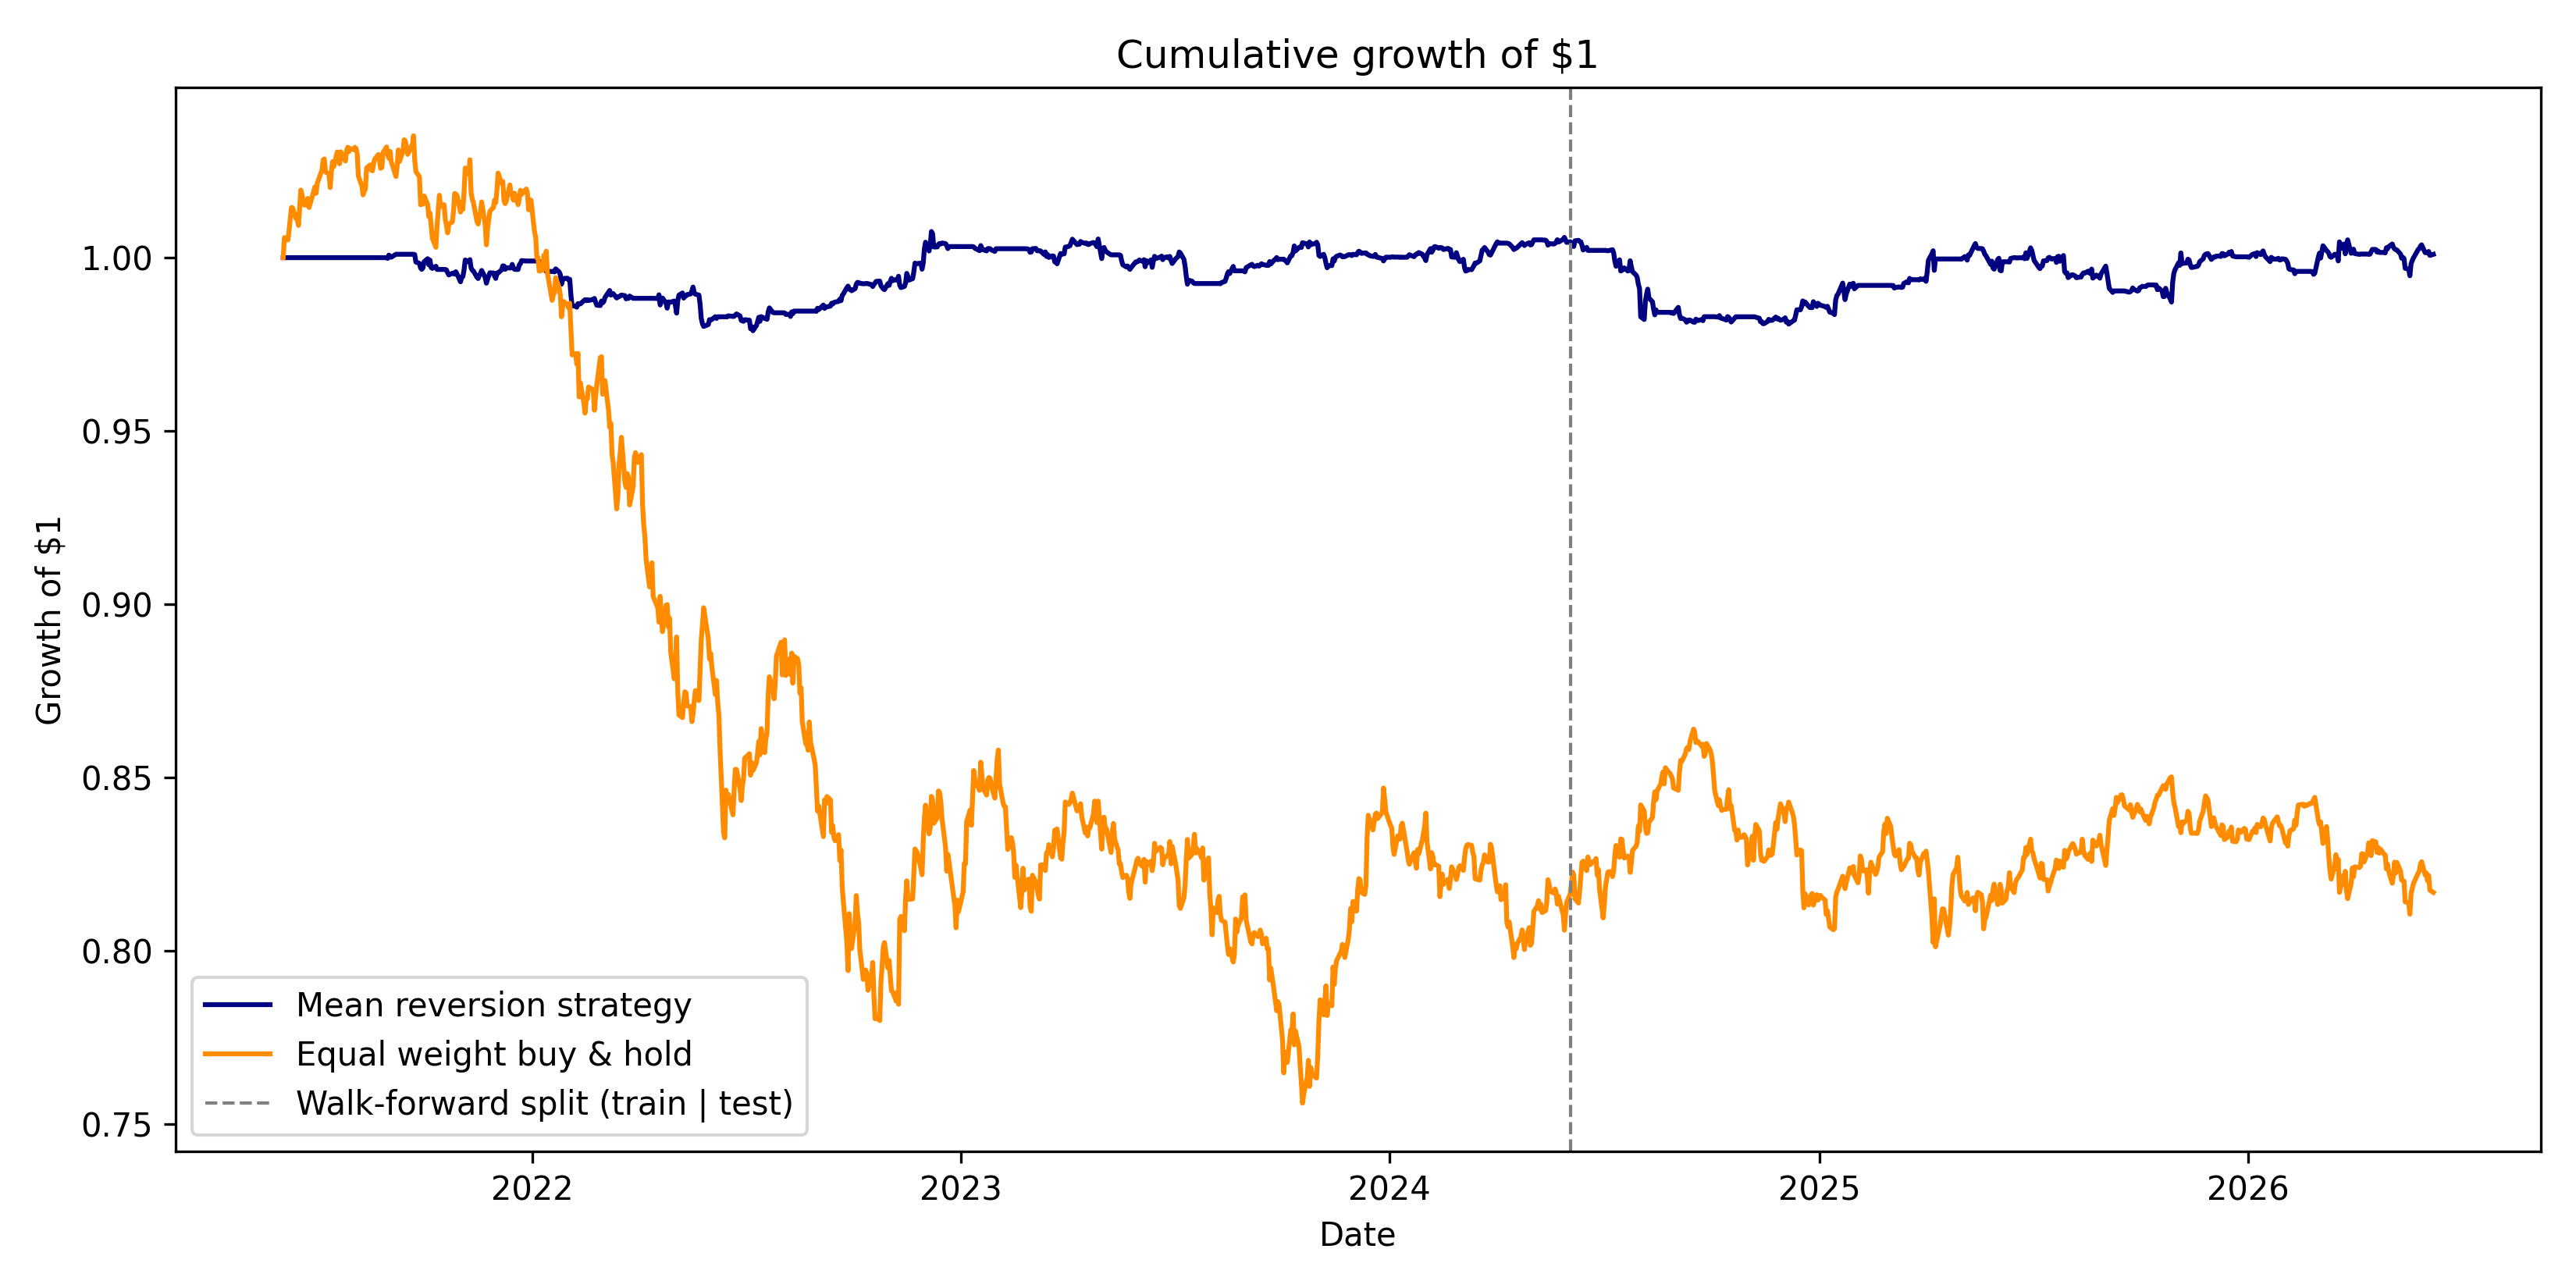

Figure 7. Cumulative growth of $1, strategy vs. equal weight benchmark.


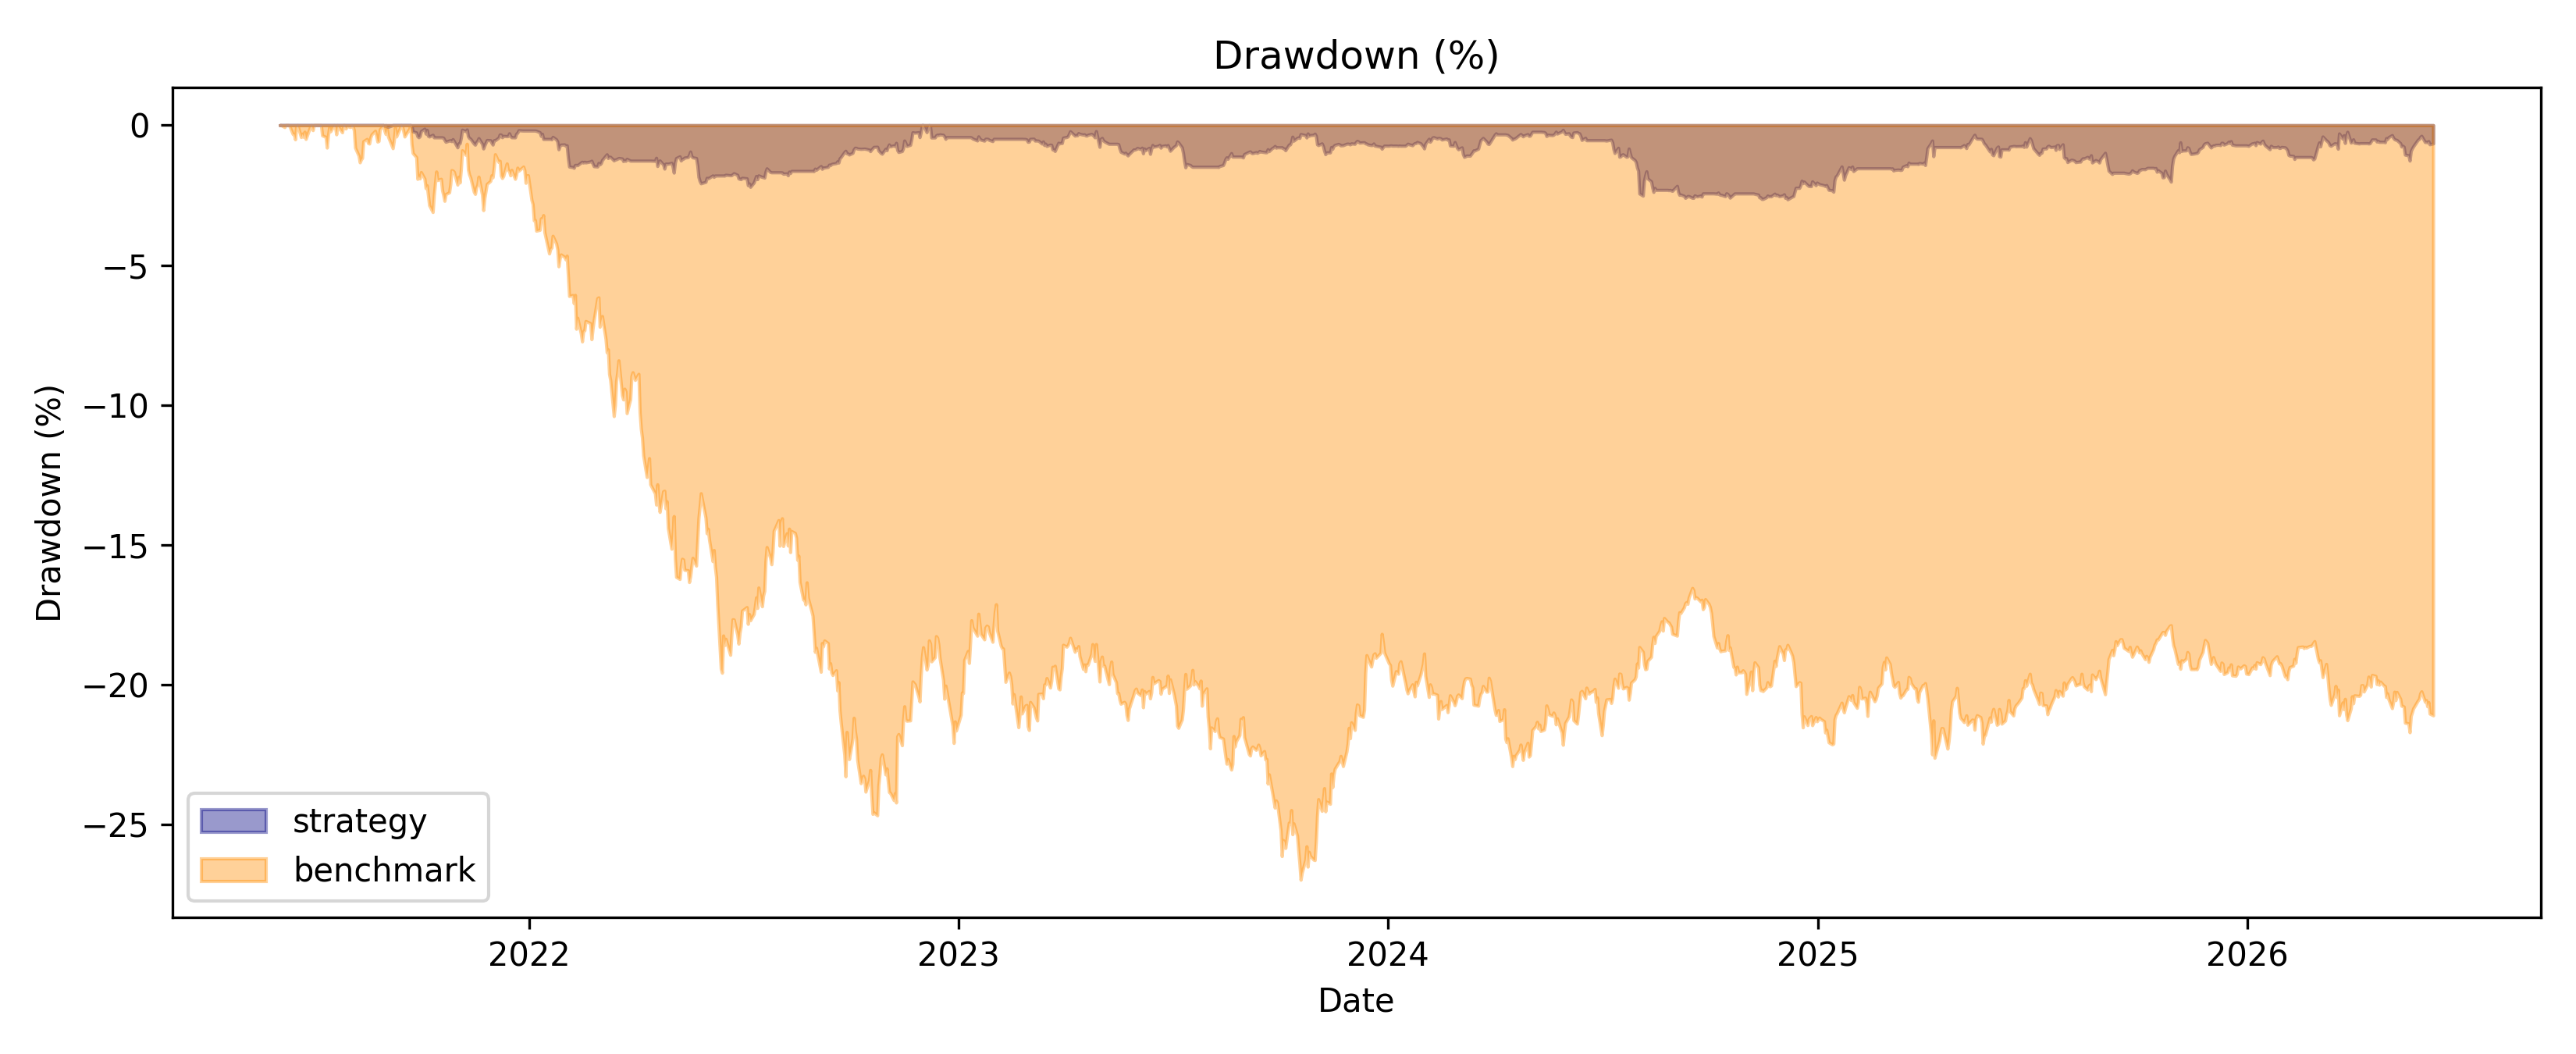

Figure 8. Drawdowns.


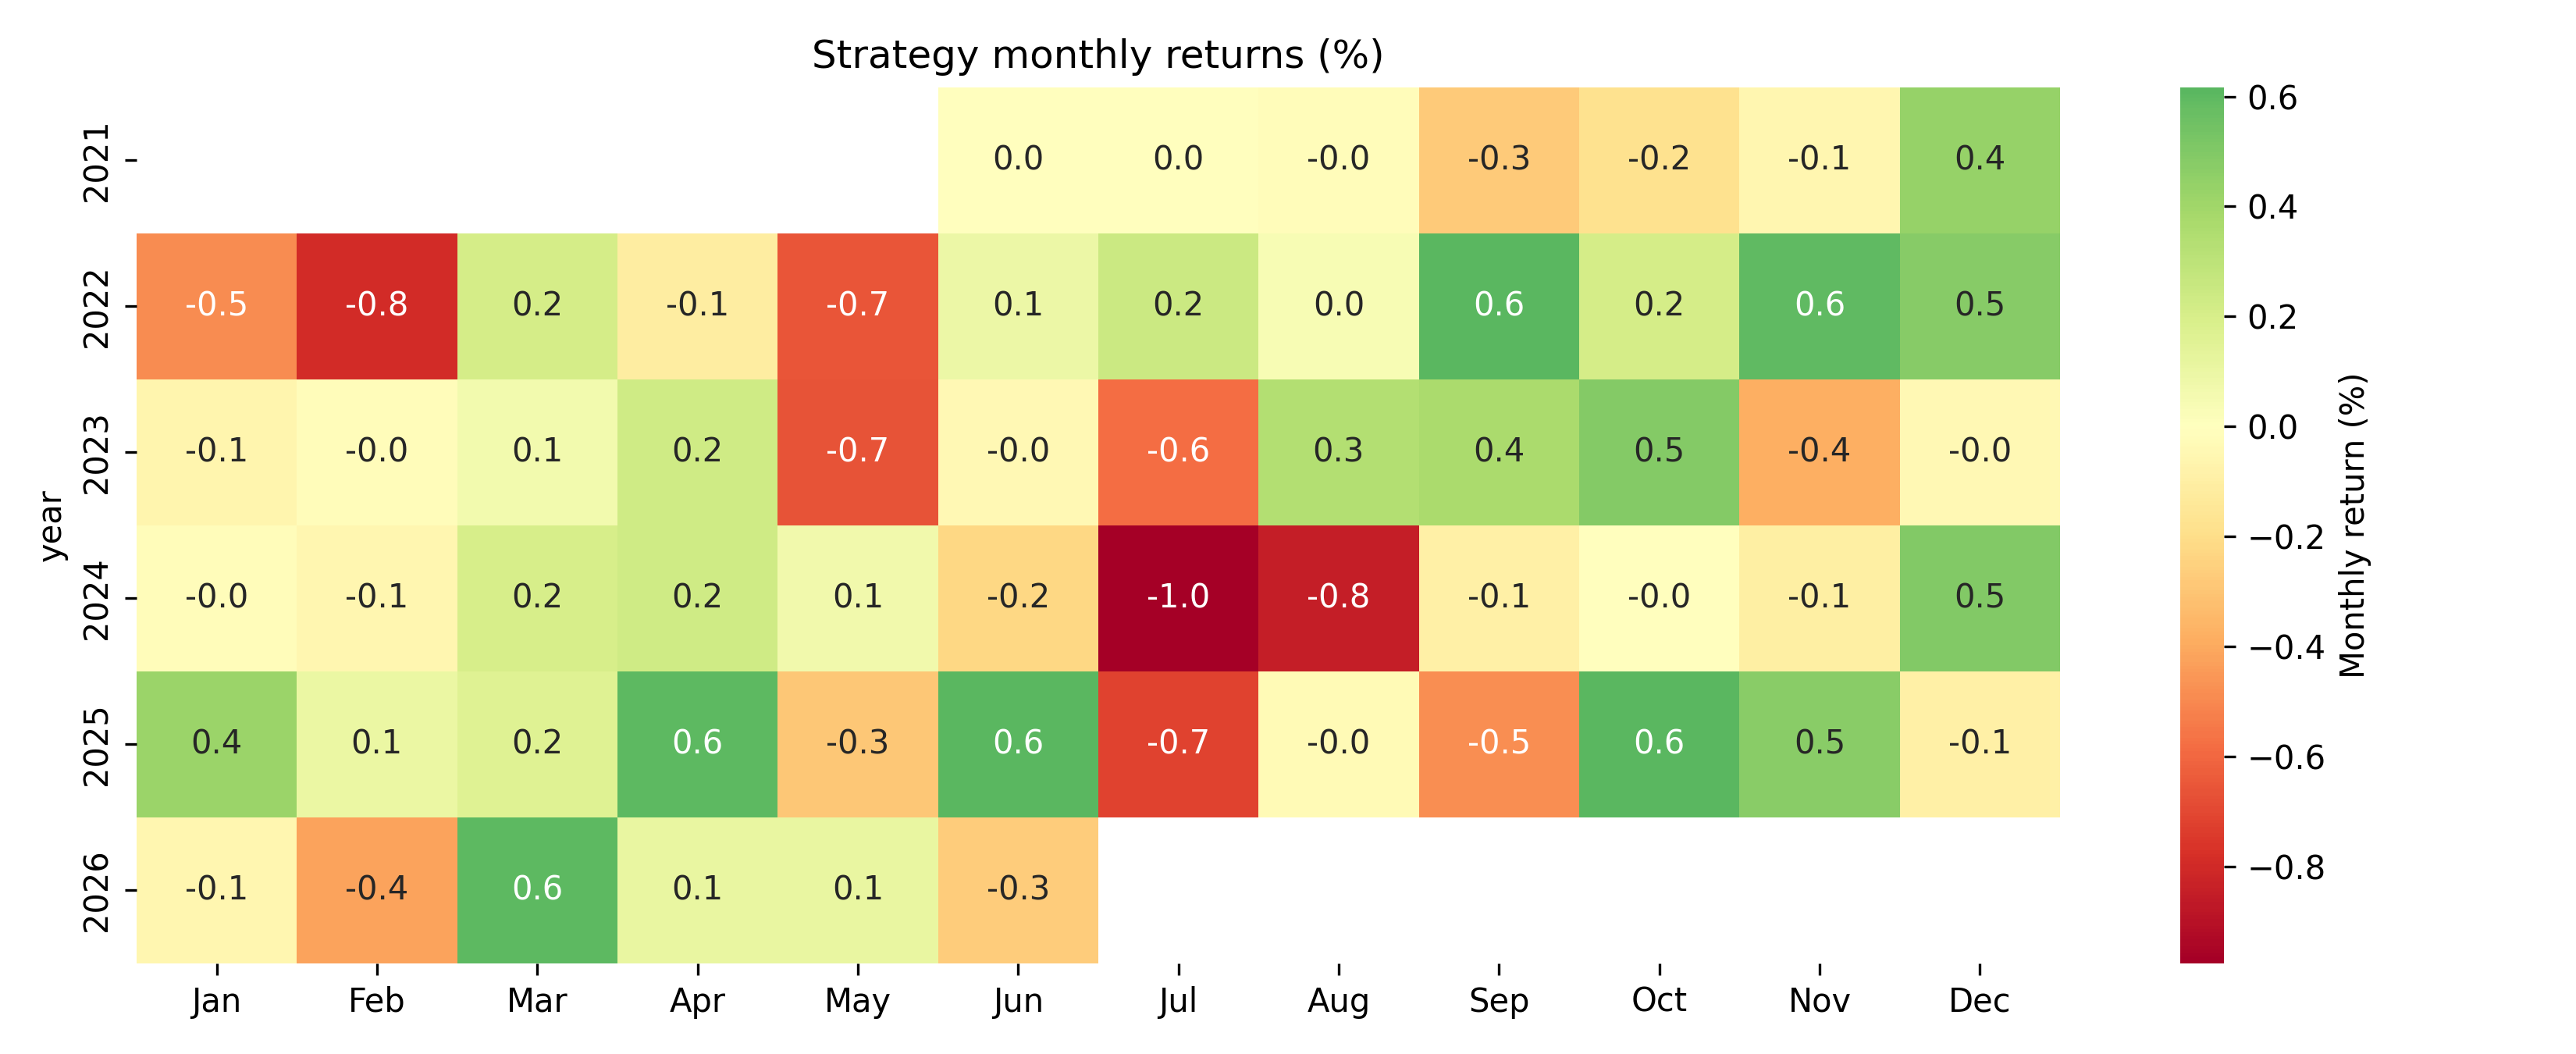

Figure 9. Strategy monthly returns.


In [13]:
display(Image(filename=config.FIGURES_DIR / "backtest_cumulative.png", width=900))
print("Figure 7. Cumulative growth of $1, strategy vs. equal weight benchmark.")
display(Image(filename=config.FIGURES_DIR / "backtest_drawdown.png", width=900))
print("Figure 8. Drawdowns.")
display(Image(filename=config.FIGURES_DIR / "monthly_returns_heatmap.png", width=900))
print("Figure 9. Strategy monthly returns.")

## 6. Conclusion

The pipeline delivers a complete template for evaluating NAV-basis mean reversion:
a normalized, cross-fund dislocation signal; event-study evidence with bootstrap
inference; regime conditioning with formal tests; and a costed, walk-forward
backtest. The binding limitation is the simulated NAV series — point estimates
validate the machinery rather than measure live inefficiency — and the natural
extensions are issuer iNAV feeds, dealer-constraint regime variables, and less
liquid universes (bank loans, EM debt, municipals) where documented premia are
larger.

The final cell assembles the SSRN-ready paper, pulling every table and figure from
the processed outputs generated above.

In [14]:
from paper import generate_paper

generate_paper.run_pipeline(rebuild=False)
paper_path = generate_paper.build_paper()
appendix_path = generate_paper.build_figures_appendix()
print("Paper:", paper_path)
print("Figures appendix:", appendix_path)

2026-06-10 07:18:50,412 | INFO     | paper.generate_paper | Pipeline stage data.fetch up to date (prices_HYG.csv exists)


2026-06-10 07:18:50,413 | INFO     | paper.generate_paper | Pipeline stage analysis.spread up to date (spreads.csv exists)


2026-06-10 07:18:50,414 | INFO     | paper.generate_paper | Pipeline stage analysis.reversion up to date (event_study_stats.csv exists)


2026-06-10 07:18:50,415 | INFO     | paper.generate_paper | Pipeline stage analysis.regime up to date (regime_stats.csv exists)


2026-06-10 07:18:50,415 | INFO     | paper.generate_paper | Pipeline stage backtest.strategy up to date (backtest_metrics.csv exists)


2026-06-10 07:18:55,087 | INFO     | paper.generate_paper | Paper written to /home/user/etf-nav-arbitrage-study/outputs/paper/etf_nav_arbitrage_study.pdf


2026-06-10 07:18:59,608 | INFO     | paper.generate_paper | Figures appendix written to /home/user/etf-nav-arbitrage-study/outputs/paper/figures_appendix.pdf


Paper: /home/user/etf-nav-arbitrage-study/outputs/paper/etf_nav_arbitrage_study.pdf
Figures appendix: /home/user/etf-nav-arbitrage-study/outputs/paper/figures_appendix.pdf
